# Example 9: Bayesian optimization using database file [(GitHub link)](https://github.com/heberlr/UQ_PhysiCell/tree/main/examples/template/ex9_Calib_BO.ipynb)

This notebook demonstrates how to perform Bayesian optimization (BO) for model calibration and parameter estimation using a custom PhysiCell model. This BO is initialized using database generated (via [GUI example](https://uq-physicell.readthedocs.io/en/latest/gui.html) or [API script](https://github.com/heberlr/UQ_PhysiCell/tree/main/examples/template/SA_script.ipynb)) from model analysis.

The observational data represents the "ground truth" generated from a single simulation with known parameter values:
- **cell_cycle_entry**: 1440.0 (mean duration of cell in quiescent mode).
- **apoptosis_rate**: 5.787e-05 (rate of cell to become apoptotic).

The *in silico* observational data ([ObsData.csv](https://github.com/heberlr/UQ_PhysiCell/tree/main/examples/template/ObsData.csv)) was generated using [GenerateData.ipynb](https://github.com/heberlr/UQ_PhysiCell/tree/main/examples/template/GenerateData.ipynb). The goal is to recover these parameter values through the optimization process.

## Import modules and set up parameters

In [1]:
from uq_physicell.bo import CalibrationContext, run_bayesian_optimization
import warnings

# Suppress numerical warnings from Gaussian Process
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
# Real values for obs. data
dic_real_value = {'cell_cycle_entry': 1440.0, 'apoptosis_rate': 5.787e-05}
# File name
db_path = "Calib_BO.db"
obs_data_path = "ObsData.csv"
# Model configuration
model_config = {
    "ini_path": "uq_config.ini", 
    "struc_name": "ModelA", 
}
# Quantities of Interest (QoI) functions
qoi_functions = {
    'live_cell_count': lambda df: len( df[ df['dead'] == False ]),
    'sum_dead_cell_count': lambda mcds_ts: sum(map(lambda mcds: len(mcds.get_cell_df()[mcds.get_cell_df()['dead'] == True]), mcds_ts))     
}
# Mapping of QoI names to observed data columns
obs_data_columns = {
    'time': "Time", 
    "live_cell_count": "Live_Cells", 
    "sum_dead_cell_count": "Sum_Dead_Cells"
}

# Bayesian Optimization options
bo_options = {
    "db_path_initial_samples": "Simulations.db",  # Database with initial samples
    "num_iterations": 30,  # More iterations for better exploration
    "batch_size_per_iteration": 1,  # Single candidate per iteration
    "max_workers": 5,  # Reduced for stability
}

In [2]:
# Create the calibration context
calib_context = CalibrationContext(
    db_path=db_path,
    obsData=obs_data_path,
    obsData_columns=obs_data_columns,
    model_config=model_config,
    qoi_functions=qoi_functions,
    bo_options=bo_options,
)
# Run the Bayesian Optimization calibration
run_bayesian_optimization(calib_context)

2026-01-23 10:33:09,288 - INFO - 🧪 Initial samples will be generated from existing database at Simulations.db.
2026-01-23 10:33:09,290 - INFO - 📊 Estimating weights from observational data ranges:
  📈 live_cell_count - weight: 2.13e-05 (range=1.52e+03)
  📈 sum_dead_cell_count - weight: 9.58e-04 (range=1.04e+03)

2026-01-23 10:33:09,291 - INFO - 🔧 CalibrationContext initialized with 5 max workers, 5 inner workers, and 1 outer workers.
2026-01-23 10:33:09,291 - INFO - 🆕 Starting fresh optimization with database: Calib_BO.db
2026-01-23 10:33:09,294 - INFO - 🧪 Generating initial samples from Simulations.db...
2026-01-23 10:33:47,443 - INFO - 🔬 Detected multiple QoIs - using multi-objective Bayesian optimization loop.
2026-01-23 10:33:47,445 - INFO - ============================================================
2026-01-23 10:33:47,446 - INFO - 🔄 Multi-Objective BO Iteration 1/30
2026-01-23 10:33:47,446 - INFO - ============================================================
2026-01-23 10:33:47,

## Obtain the Pareto front point(s)

🔍 COMPREHENSIVE PARETO ANALYSIS

📊 Extracting all Pareto points ...
🎯 Current Pareto front size: 5

🎯 CURRENT PARETO FRONT:
   Number of Pareto optimal points: 5
   Sample IDs: [4, 13, 16, 39, 67]

   📋 Pareto Front Details:
   Point 1 (Sample 4):
      Fitness: {'live_cell_count': np.float64(0.5649144394341963), 'sum_dead_cell_count': np.float64(0.8559025559873279)}
      Parameters: {'apoptosis_rate': 5.98522630694583e-05, 'cell_cycle_entry': 1559.1182049626123}
   Point 2 (Sample 13):
      Fitness: {'live_cell_count': np.float64(0.7012471264348298), 'sum_dead_cell_count': np.float64(0.6433052738103898)}
      Parameters: {'apoptosis_rate': 5.763103537976935e-05, 'cell_cycle_entry': 1461.3241750226885}
   Point 3 (Sample 16):
      Fitness: {'live_cell_count': np.float64(0.7159452132609072), 'sum_dead_cell_count': np.float64(0.38833271268108394)}
      Parameters: {'apoptosis_rate': 5.763103537976935e-05, 'cell_cycle_entry': 1461.3241750226885}
   Point 4 (Sample 39):
      Fitness:

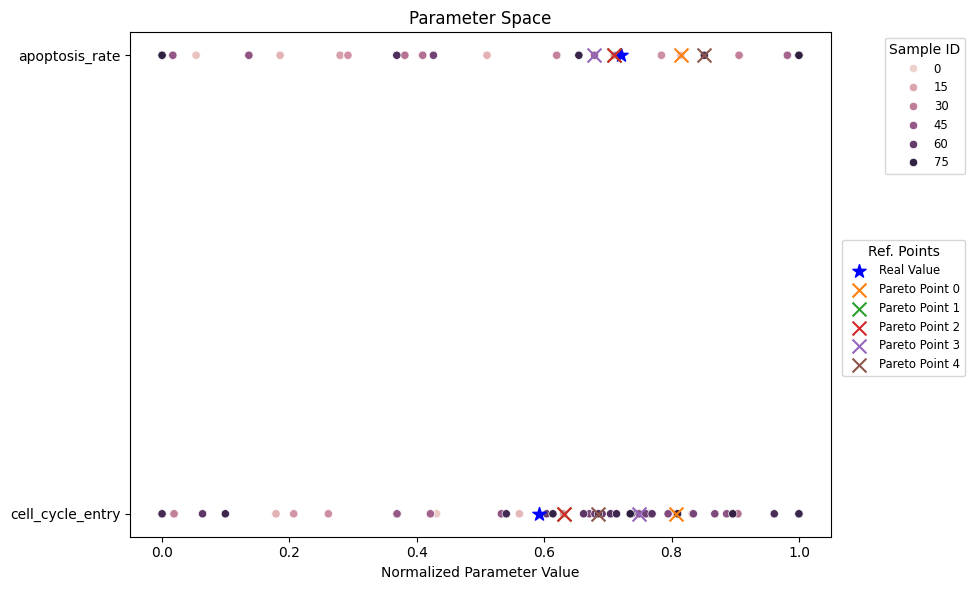

In [3]:
from uq_physicell.bo import load_structure, analyze_pareto_results, plot_parameter_space, get_observed_qoi
# Load the database and perform analysis
df_metadata, df_param_space, df_qois, df_gp_models, df_samples, df_output = load_structure(db_path)
# Comprehensive Pareto analysis
pareto_data = analyze_pareto_results(df_qois, df_samples, df_output)
# Plot with pareto front points
pareto_points = {f"Pareto Point {i}": param for i, param in enumerate(pareto_data['pareto_front']['parameters'])}
plot_parameter_space(df_samples, df_param_space, params=pareto_points, real_value=dic_real_value)
df_obs_qoi = get_observed_qoi(df_metadata['ObsData_Path'].values[0], df_qois)


## Vizualize QoIs from Pareto front point(s)

Plotting live_cell_count
Sample ID: [4, 13, 16, 39, 67]
Objective Function Values:
{'live_cell_count': np.float64(0.5649144394341963), 'sum_dead_cell_count': np.float64(0.8559025559873279)}
Noise of Objective Function:
{'live_cell_count': np.float64(0.22746576091514747), 'sum_dead_cell_count': np.float64(0.18779938784786435)}
Sample ID: [4, 13, 16, 39, 67]
Objective Function Values:
{'live_cell_count': np.float64(0.5649144394341963), 'sum_dead_cell_count': np.float64(0.8559025559873279)}
Noise of Objective Function:
{'live_cell_count': np.float64(0.22746576091514747), 'sum_dead_cell_count': np.float64(0.18779938784786435)}
Sample ID: [4, 13, 16, 39, 67]
Objective Function Values:
{'live_cell_count': np.float64(0.5649144394341963), 'sum_dead_cell_count': np.float64(0.8559025559873279)}
Noise of Objective Function:
{'live_cell_count': np.float64(0.22746576091514747), 'sum_dead_cell_count': np.float64(0.18779938784786435)}
Plotting sum_dead_cell_count
Sample ID: [4, 13, 16, 39, 67]
Object

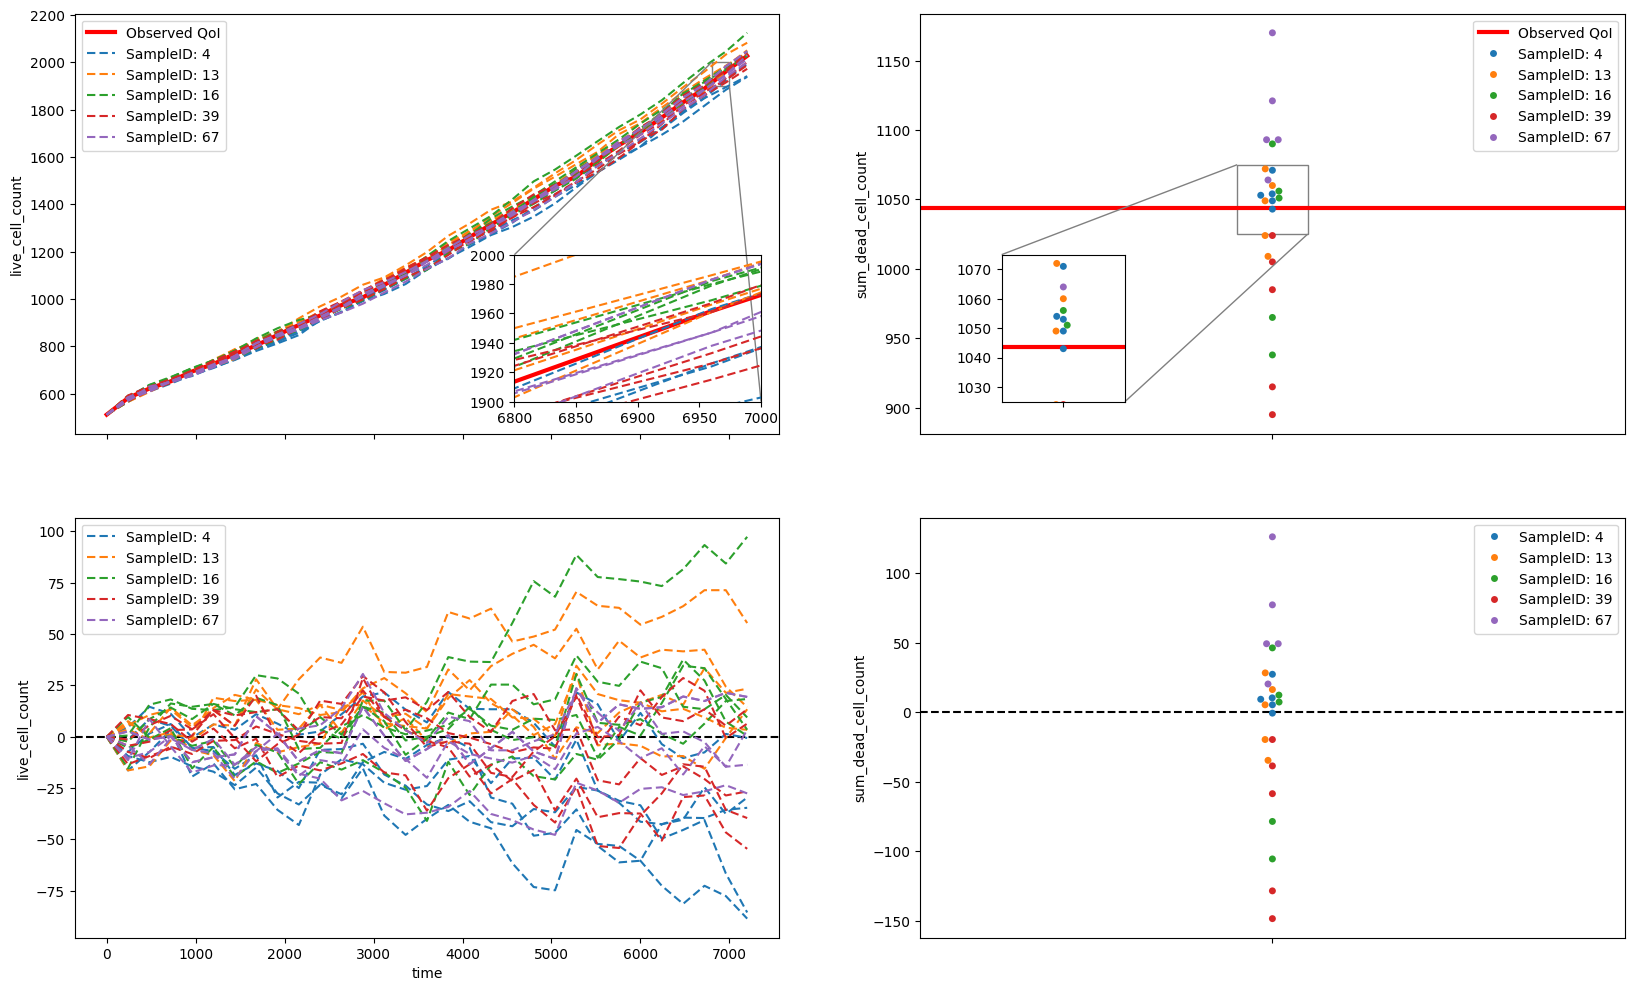

In [4]:
from uq_physicell.bo import plot_qoi_param
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), sharex='col')
# Plot QoIs of best parameters
for i, qoi in enumerate(df_qois['QoI_Name']):
    print(f"Plotting {qoi}")
    ax_qoi = axes[0, i]
    ax_residual = axes[1, i]
    # Plot QoI values
    plot_qoi_param(df_obs_qoi, df_output, pareto_data['pareto_front']['sample_ids'], x_var='time', y_var=qoi, swarmplot=True, axis=ax_qoi)# 
    # Plot residuals
    plot_qoi_param(df_obs_qoi, df_output, pareto_data['pareto_front']['sample_ids'], x_var='time', y_var=qoi, swarmplot=True, axis=ax_residual, plot_residuals=True)#
    # Add zoomed-in inset in QoI plot
    if qoi == 'live_cell_count':
        # Insert a zoomed-in plot
        axins = inset_axes(ax_qoi, width="35%", height="35%", loc="lower right", bbox_to_anchor=(-0.01, 0.05, 1, 1), bbox_transform=ax_qoi.transAxes, borderpad=0.8)
        plot_qoi_param(df_obs_qoi, df_output, pareto_data['pareto_front']['sample_ids'], x_var='time', y_var=qoi, axis=axins)# 
        axins.set_xlim(6800,7000)
        axins.set_ylim(1900, 2000)
        axins.set(xlabel='', ylabel='')
        axins.get_legend().set_visible(False)
    else:
        # Insert a zoomed-in plot
        axins = inset_axes(ax_qoi, width="35%", height="35%", loc="lower left", bbox_to_anchor=(0.1, 0.05, 0.5, 1), bbox_transform=ax_qoi.transAxes, borderpad=0.8)
        plot_qoi_param(df_obs_qoi, df_output, pareto_data['pareto_front']['sample_ids'], x_var='time', y_var=qoi, swarmplot=True, axis=axins)#
        axins.set_xlim(-0.05, 0.05)
        axins.set_ylim(1025, 1075)
        axins.set(xlabel='', ylabel='')
        axins.get_legend().set_visible(False)
    mark_inset(ax_qoi, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.savefig('QoIs_BO.svg', format='svg')


## Vizualize the QoIs fitness vs Parameters values

Plotting cell_cycle_entry vs live_cell_count
Plotting cell_cycle_entry vs sum_dead_cell_count
Plotting apoptosis_rate vs live_cell_count
Plotting apoptosis_rate vs sum_dead_cell_count


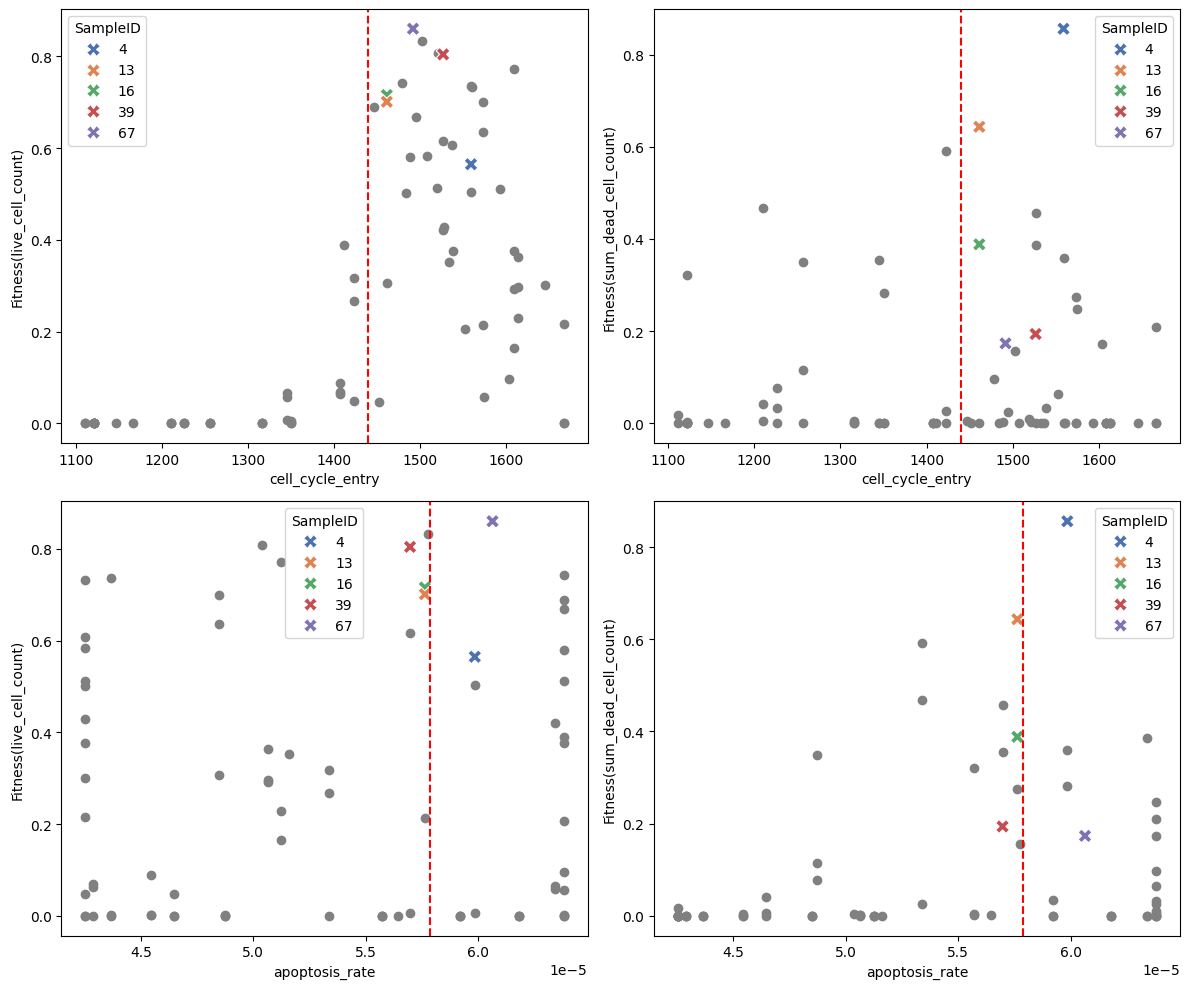

In [5]:
from uq_physicell.bo import plot_parameter_vs_fitness
# Plot each parameter vs each QoI
fig, axes = plt.subplots(len(df_param_space), len(df_qois['QoI_Name']), figsize=(12, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Increased spacing
for i, param in enumerate(df_param_space['ParamName']):
    for j, qoi in enumerate(df_qois['QoI_Name']):
        print(f"Plotting {param} vs {qoi}")
        plot_parameter_vs_fitness(df_samples, df_output, param, qoi, samples_id=pareto_data['pareto_front']['sample_ids'], axis= axes[i, j])
        # Plot real value
        axes[i, j].axvline(dic_real_value[param], color='red', linestyle='--', label='Real Value')

# Ensure proper layout and save the figure
plt.tight_layout()  # This will automatically adjust spacing to prevent overlaps

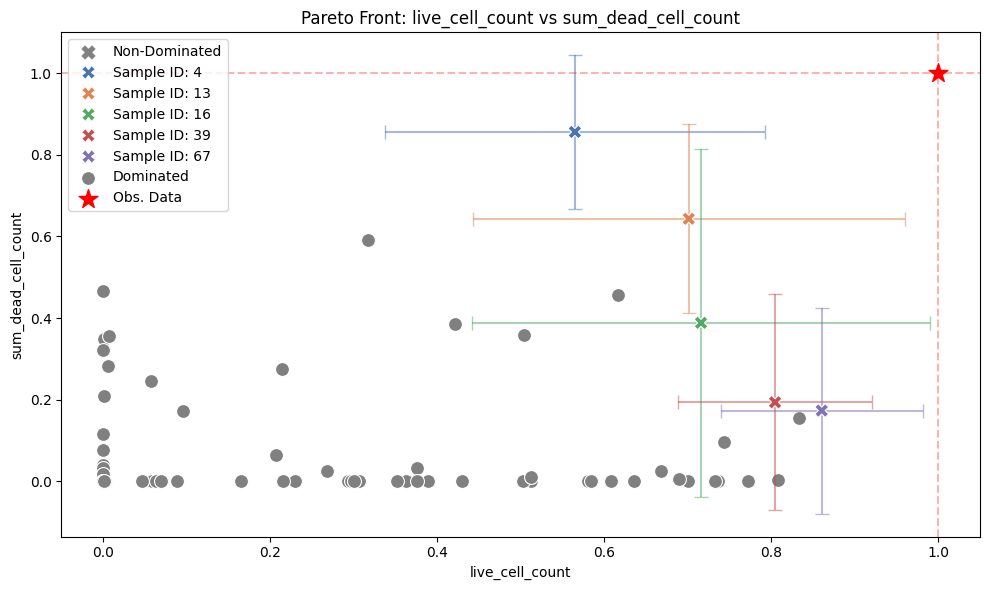

In [6]:
from uq_physicell.bo.plots import plot_pareto_front
plot_pareto_front(df_output, 'live_cell_count', 'sum_dead_cell_count', samples_id=pareto_data['pareto_front']['sample_ids'], plot_std=True)
plt.savefig(f'Pareto_front_BO.svg', format='svg')

In [8]:
from uq_physicell.model_analysis import ModelAnalysisContext, run_simulations



db_path = "PostCalibData.db"  # Path to the database file
model_config = {"ini_path": "uq_config.ini", "struc_name": "ModelA"} # Example model configuration
sampler = 'Custom'  # Example sampler
params_info = { # Example parameters information
    'cell_cycle_entry': {'ref_value': 1440.0, 'perturbation': None},
    'apoptosis_rate': {'ref_value': 5.787e-05, 'perturbation': None}
}  

# Create Model Analysis Context
context = ModelAnalysisContext(db_path, model_config, sampler, params_info, qois_info={}, num_workers=8)
# Sample parameter sets and run simulations
pareto_points = pareto_data['pareto_front']['sample_ids']
context.dic_samples = df_samples[df_samples['SampleID'].isin(pareto_points)].pivot(index="SampleID", columns="ParamName", values="ParamValue").to_dict(orient='index')
context.dic_samples[0] = dic_real_value
run_simulations(context)


Simulations completed and results stored in the database: PostCalibData.db.


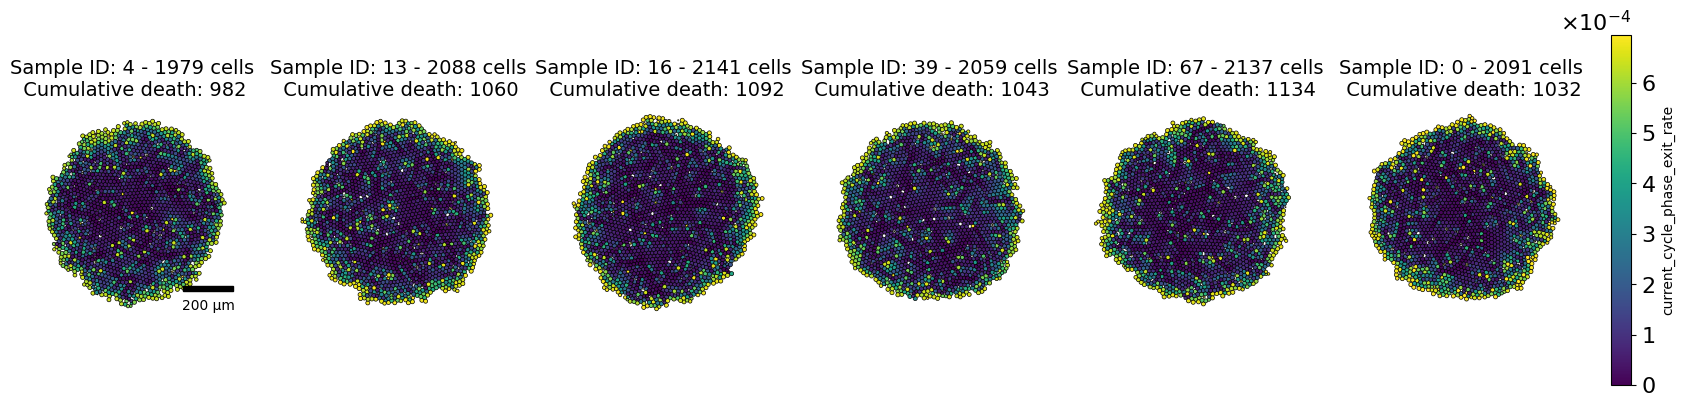

In [9]:
from uq_physicell.model_analysis import load_output as load_output_ma
from uq_physicell.model_analysis import plot_cells_2D
import pandas as pd
import matplotlib.ticker as ticker



replicate_id = 0  # Assuming you want to load the first replicate
feature = 'current_cycle_phase_exit_rate'  # feature to plot in cmap
min_value = 0.0; max_value = 1/pd.DataFrame(context.dic_samples).T.min()['cell_cycle_entry']
df_qois_data_selected = load_output_ma(db_path, sample_ids=pareto_points+[0], replicate_ids=[replicate_id], load_data=True)
fig, axes = plt.subplots(1, 6, figsize=(20, 5), sharex=True, sharey=True)

for ax_id, sample_id in enumerate(pareto_points+[0]):
    mcds_timeseries = df_qois_data_selected[df_qois_data_selected['SampleID'] == sample_id].iloc[0]['Data']
    mcds_last_time = mcds_timeseries[-1] # Get the last time point of the time series for the current sample
    cumulative_death = qoi_functions['sum_dead_cell_count'](mcds_timeseries)
    df_cell = mcds_last_time.get_cell_df()
    if mcds_last_time.get_time() != 7200:
        print(f"Sample ID {sample_id} has last time {mcds_last_time.get_time()} instead of 7200")
    last_collection = plot_cells_2D(df_cell, ax=axes[ax_id], scale_bar=True if (ax_id==0) else False, feature=feature, cmap='viridis', vmin=min_value, vmax=max_value)
    axes[ax_id].set_title(f'Sample ID: {sample_id} - {len(df_cell)} cells\n Cumulative death: {cumulative_death}', fontsize=14)

# cbar = fig.colorbar(last_collection, ax=axes[-1], fraction=0.05, pad=0.02)    
fig.subplots_adjust(right=0.90)
cax = fig.add_axes([0.92, 0.15, 0.01, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(last_collection, cax=cax)
# Configure the formatter to use scientific notation
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2)) # Adjusts when sci-notation kicks in
cbar.ax.tick_params(labelsize=16)               # tick labels
cbar.ax.yaxis.get_offset_text().set_size(16)    # scientific notation text (e.g., ×10⁻³)
cbar.ax.yaxis.set_major_formatter(formatter)
cbar.set_label(feature)
# plt.tight_layout()
plt.savefig(f'last_snapshots_{feature}_pareto_points.svg', format='svg')
